In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

import joblib

In [2]:
df = pd.read_csv("india_2000_2024_daily_weather.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
    city        date  temperature_2m_max  temperature_2m_min  \
0  Delhi  01-01-2000                19.9                 7.4   
1  Delhi  02-01-2000                20.0                 5.5   
2  Delhi  03-01-2000                20.1                 6.3   
3  Delhi  04-01-2000                19.8                 6.4   
4  Delhi  05-01-2000                19.4                 5.3   

   apparent_temperature_max  apparent_temperature_min  precipitation_sum  \
0                      19.2                       5.8                0.0   
1                      18.9                       3.4                0.0   
2                      18.2                       4.3                0.0   
3                      18.5                       4.2                0.0   
4                      17.7                       3.2                0.0   

   rain_sum  weather_code  wind_speed_10m_max  wind_gusts_10m_max  \
0       0.0             0                10.9                

In [3]:

print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 city                           0
date                           0
temperature_2m_max             0
temperature_2m_min             0
apparent_temperature_max       0
apparent_temperature_min       0
precipitation_sum              0
rain_sum                       0
weather_code                   0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
dtype: int64


In [4]:
df = df[['city', 'date', 'temperature_2m_max']]

In [5]:

df.columns = ['City', 'Date', 'Temperature']

In [26]:

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

In [27]:
df = df.dropna()

In [28]:
df['Year'] = df['Date'].dt.year

In [29]:
city_df = df[df['City'] == 'Mumbai']

print("\nCity Data Shape:", city_df.shape)


City Data Shape: (9132, 5)


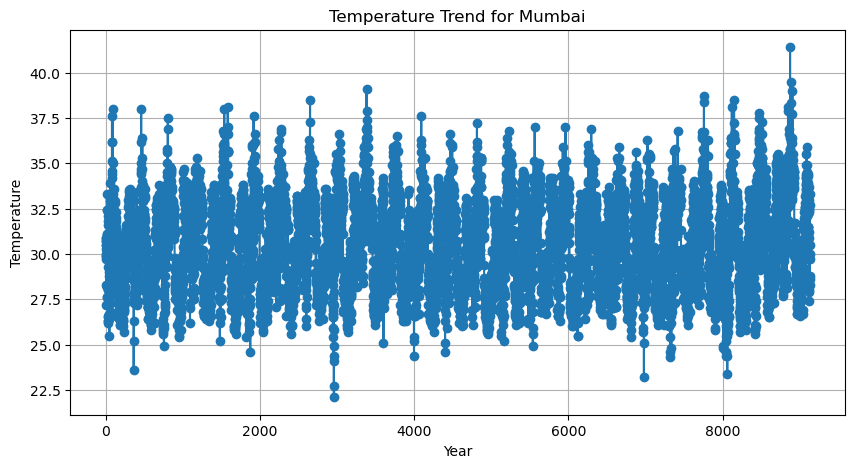

In [30]:
plt.figure(figsize=(10,5))
plt.plot(city_df['Days'], city_df['Temperature'], marker='o')
plt.title("Temperature Trend for Mumbai")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.grid()
plt.show()

In [31]:
X = city_df[['Days']]
y = city_df['Temperature']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("\nModel Performance:")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


Model Performance:
R2 Score: -0.0017676511062312272
MAE: 2.014464252051141


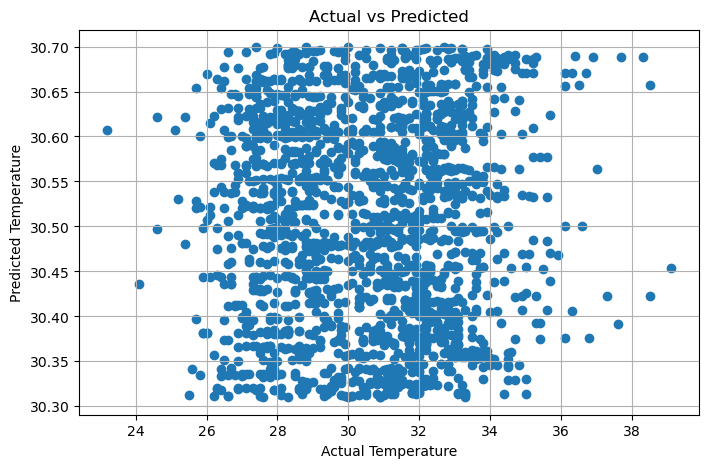

In [36]:

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

In [37]:
last_day = city_df['Days'].max()

# Create future days in 5-day gaps (next 30 days)
future_days = pd.DataFrame({
    'Days': [last_day + i for i in range(5, 35, 5)]
})

# Predict
future_preds = model.predict(future_days)

print("\nFuture Predictions (5-day gaps):")
for d, pred in zip(future_days['Days'], future_preds):
    print(f"After {d - last_day} days: {pred:.2f} °C")


Future Predictions (5-day gaps):
After 5 days: 30.70 °C
After 10 days: 30.70 °C
After 15 days: 30.70 °C
After 20 days: 30.70 °C
After 25 days: 30.70 °C
After 30 days: 30.70 °C
